<a href="https://colab.research.google.com/github/KandyalaYaswanthSai/21691a31j5-/blob/main/Pneumonia_Detection_and_Severity_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import cv2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Dataset Loading from ZIP File
import zipfile
import os
# Path to the uploaded zip file
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/chest_xray.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()
print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
# Enhanced Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
# Training Data Generator
train_images = "/content/chest_xray/train"
train_generator = train_datagen.flow_from_directory(
    train_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode="grayscale"
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Test Data Generator
test_images = "/content/chest_xray/test"
test_generator = test_datagen.flow_from_directory(
    test_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode="grayscale"
)

# Validation Data Generator
validation_images = "/content/chest_xray/val"
validation_generator = test_datagen.flow_from_directory(
    validation_images,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode="grayscale"
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 622 images belonging to 2 classes.


In [ ]:
train_generator.class_indices


{'NORMAL': 0, 'PNEUMONIA': 1}

In [ ]:
# ConvXNet Model Definition
def ConvXNet(input_shape=(224, 224, 1)):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # ConvXNet Block 1
    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # ConvXNet Block 2
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # ConvXNet Block 3
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # ConvXNet Block 4
    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Fully Connected Layers
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.models.Model(inputs, x)
    return model


In [ ]:
model = ConvXNet()

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,993,889 (102.97 MB)

 Trainable params: 26,993,889 (102.97 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_generator, epochs=50,validation_data=validation_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 495ms/step - accuracy: 0.7335 - loss: 0.5866 - val_accuracy: 0.7901 - val_loss: 0.4341
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 431ms/step - accuracy: 0.8322 - loss: 0.3784 - val_accuracy: 0.8317 - val_loss: 0.3862
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.8562 - loss: 0.3196 - val_accuracy: 0.8125 - val_loss: 0.4116
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 438ms/step - accuracy: 0.8695 - loss: 0.2943 - val_accuracy: 0.7933 - val_loss: 0.4200
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 424ms/step - accuracy: 0.8636 - loss: 0.3085 - val_accuracy: 0.7965 - val_loss: 0.4312
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 429ms/step - accuracy: 0.8729 - loss: 0.2865 - val_accuracy: 0.7901 - val_loss: 0.4450
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 408ms/step - accuracy: 0.8734 - loss: 0.2787 - val_accuracy: 0.7628 - val_loss: 0.4940
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 439ms/step - accuracy: 0.8755 - loss: 

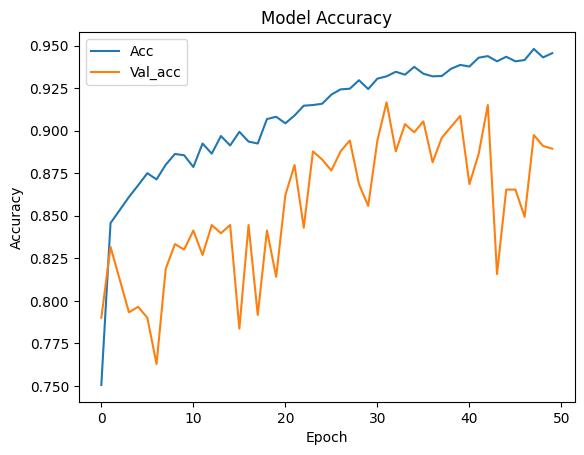

In [ ]:
#Visulaize the accuracy in each epoch
plt.plot(history.history['accuracy'],label='Acc')
plt.plot(history.history['val_accuracy'],label='Val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

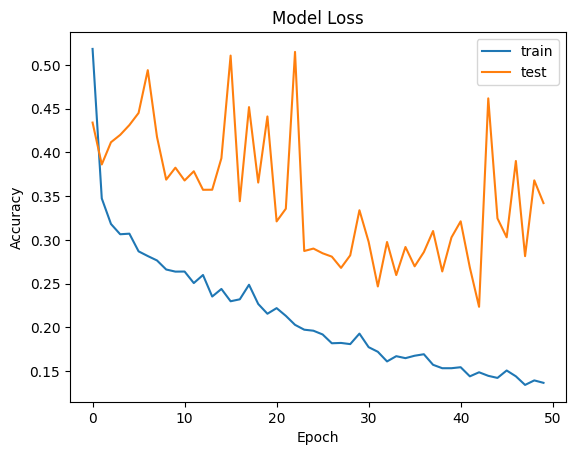

In [ ]:
#Visulaize the Loss in each epoch
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Normal


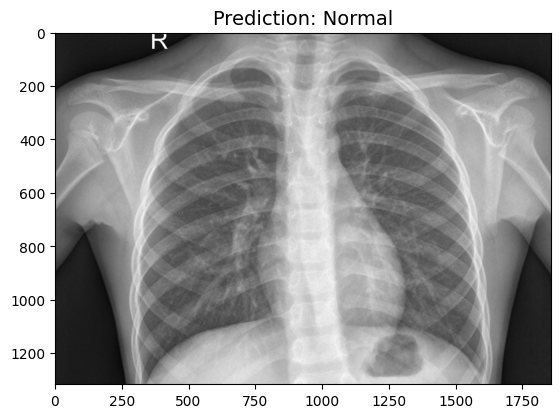

In [ ]:
import cv2
import matplotlib.pyplot as plt

def predict_pneumonia(model, img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Read image in grayscale
    tempimg = img.copy()  # Keep copy
    img = cv2.resize(img, (224, 224)) # Resize to match model input size
    img = img / 255.0 # Normalize
    img = img.reshape(1, 224, 224, 1) # Reshape to match model input (batch_size, height, width, channels)
    prediction = model.predict(img)  # prediction

    prediction_label = "Pneumonia" if prediction.item() >= 0.5 else "Normal"
    print("Prediction:", prediction_label)
    plt.imshow(tempimg, cmap='gray')
    plt.title(f"Prediction: {prediction_label}", fontsize=14)
    plt.show()

#Example :
predict_pneumonia(model, "/content/IM-0001-0001.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction: Pneumonia


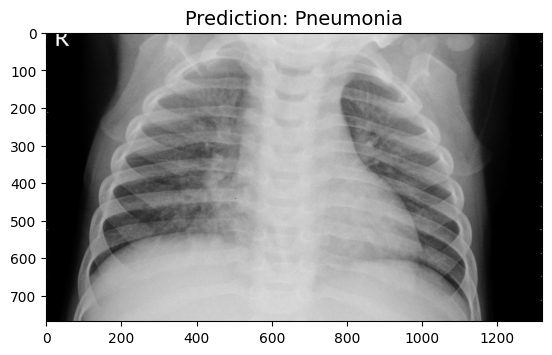

In [ ]:
predict_pneumonia(model, "/content/person65_virus_123.png")

In [ ]:
# Saving Model
model.save('/content/convxnet_model.h5')
print("Model saved in Colab storage!")

Model saved in Colab storage!


In [ ]:
# Save the model in Google Drive
model.save('/content/drive/MyDrive/convxnet_model.h5')
print("Model saved in Google Drive!")

Model saved in Google Drive!


**Using Custom CNN Architecture**

In [ ]:
# Custom CNN Model Definition
def CustomCNN(input_shape=(224, 224, 1)):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(inputs)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Block 4
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Block 5
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPool2D(2,2)(x)

    # Fully Connected Layers
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    # Define Model
    modell = tf.keras.models.Model(inputs, x)
    return modell

In [ ]:
modell = CustomCNN()

In [ ]:
modell.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 222, 222, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 109, 109, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 52, 52, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 10, 10, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,196,289 (4.56 MB)

 Trainable params: 1,196,289 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modell.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['accuracy'])

In [ ]:
historyy = modell.fit(train_generator, epochs = 50, validation_data = validation_generator)

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 447ms/step - accuracy: 0.7311 - loss: 0.5624 - val_accuracy: 0.7395 - val_loss: 0.5488
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 390ms/step - accuracy: 0.8345 - loss: 0.3441 - val_accuracy: 0.7878 - val_loss: 0.4535
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 382ms/step - accuracy: 0.8661 - loss: 0.3101 - val_accuracy: 0.7669 - val_loss: 0.5284
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 392ms/step - accuracy: 0.8722 - loss: 0.2888 - val_accuracy: 0.8392 - val_loss: 0.3938
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 395ms/step - accuracy: 0.8833 - loss: 0.2716 - val_accuracy: 0.8489 - val_loss: 0.3450
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 393ms/step - accuracy: 0.8893 - loss: 0.2512 - val_accuracy: 0.7605 - val_loss: 0.5831
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 397ms/step - accuracy: 0.8935 - loss: 0.2511 - val_accuracy: 0.7621 - val_loss: 0.4405
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 404ms/step - accuracy: 0.8982 - loss: 0

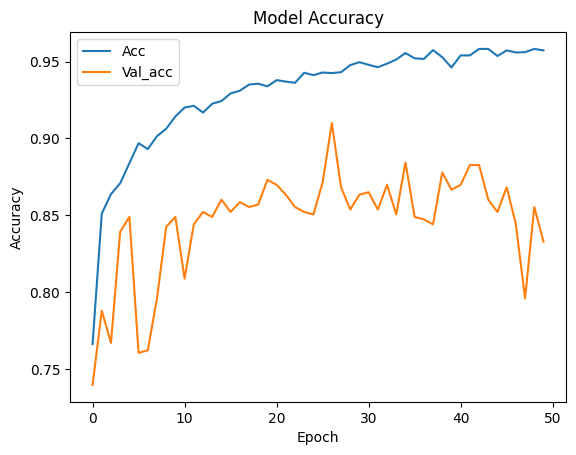

In [ ]:
#Visulaize the accuracy in each epoch
plt.plot(historyy.history['accuracy'],label='Acc')
plt.plot(historyy.history['val_accuracy'],label='Val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

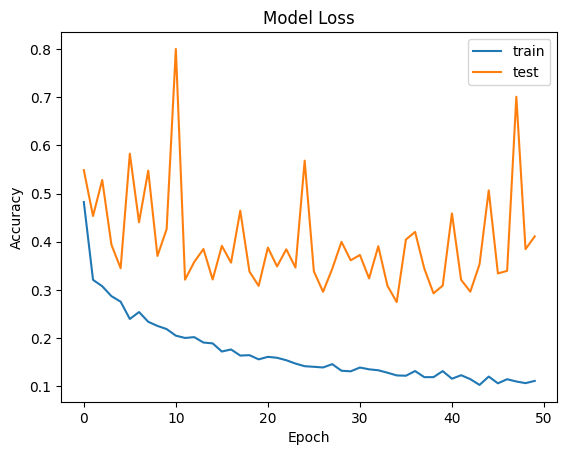

In [ ]:
#Visulaize the Loss in each epoch
import matplotlib.pyplot as plt
plt.plot(historyy.history['loss'],label='train')
plt.plot(historyy.history['val_loss'],label='test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
Prediction: Normal


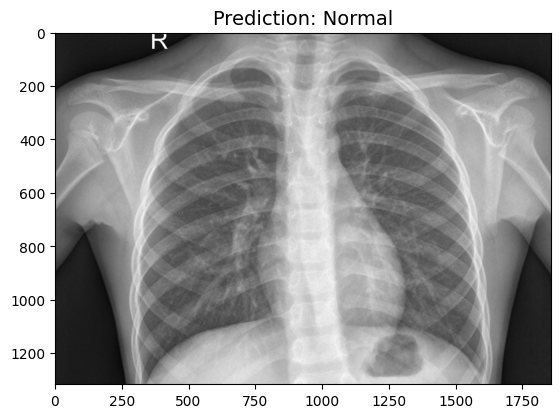

In [ ]:
import cv2
import matplotlib.pyplot as plt

def predict_pneumonia(model, img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Read image in grayscale
    tempimg = img.copy()  # Keep copy
    img = cv2.resize(img, (224, 224)) # Resize to match model input size
    img = img / 255.0 # Normalize
    img = img.reshape(1, 224, 224, 1) # Reshape to match model input (batch_size, height, width, channels)
    prediction = modell.predict(img)  # prediction

    prediction_label = "Pneumonia" if prediction.item() >= 0.5 else "Normal"
    print("Prediction:", prediction_label)
    plt.imshow(tempimg, cmap='gray')
    plt.title(f"Prediction: {prediction_label}", fontsize=14)
    plt.show()

#Example :
predict_pneumonia(modell, "/content/IM-0001-0001.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: Pneumonia


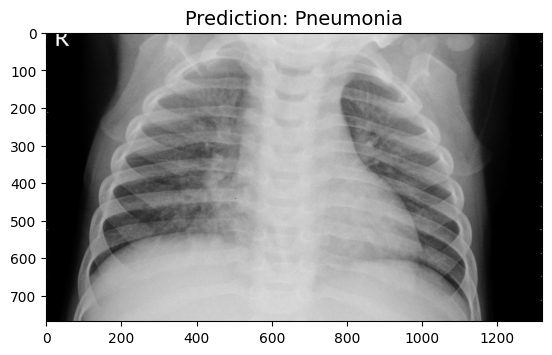

In [ ]:
predict_pneumonia(modell, "/content/person65_virus_123.png")

In [ ]:
modell.save('/content/customcnn_model.h5')
print("Model saved in Colab storage!")


Model saved in Colab storage!


In [ ]:
# Save the model in Google Drive
modell.save('/content/drive/MyDrive/convxnet_model.h5')
print("Model saved in Google Drive!")

Model saved in Google Drive!


In [ ]:
from tensorflow.keras.models import load_model
modell = load_model("/content/customcnn_model.h5")
print("Models loaded successfully!")


Models loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Pneumonia


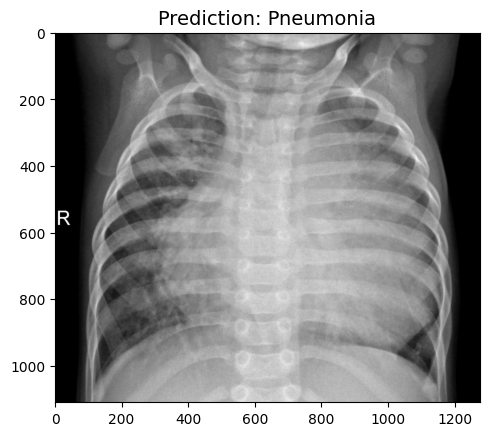

In [ ]:
import cv2
import matplotlib.pyplot as plt

def predict_pneumonia(model, img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Read image in grayscale
    tempimg = img.copy()  # Keep copy
    img = cv2.resize(img, (224, 224)) # Resize to match model input size
    img = img / 255.0 # Normalize
    img = img.reshape(1, 224, 224, 1) # Reshape to match model input (batch_size, height, width, channels)
    prediction = modell.predict(img)  # prediction

    prediction_label = "Pneumonia" if prediction.item() >= 0.5 else "Normal"
    print("Prediction:", prediction_label)
    plt.imshow(tempimg, cmap='gray')
    plt.title(f"Prediction: {prediction_label}", fontsize=14)
    plt.show()

#Example :
predict_pneumonia(modell, "/content/person5_bacteria_15.png")
